# 📊 Projet SAE — IPO | Test de l'hypothèse H2 : L'Underpricing

**ING1 - FISA Mathématiques Appliquées | Année 2025–2026**

---

## 🎯 Rappel de l'hypothèse H2

> **H2 – Underpricing :** Le rendement moyen au premier jour de cotation (underpricing) est statistiquement **plus faible** pour la cohorte 2022–2024 (période de taux élevés) que pour la cohorte 2019–2021 (période de taux bas).  
> Cette hypothèse sera testée par le **test de Mann-Whitney** et confirmée par une **régression OLS**, qui permettra d'isoler l'effet propre des taux d'intérêt *toutes choses égales par ailleurs*.

---

## 📌 Ce que ce notebook va faire

| Étape | Ce qu'on fait |
|---|---|
| 1 | Chargement des fichiers |
| 2 | Exploration du dataset |
| 3 | Nettoyage des données |
| 4 | Création des cohortes |
| 5 | Calcul et rappel de l'underpricing |
| 6 | Statistiques descriptives |
| 7 | Visualisations |
| 8 | Test de Mann-Whitney |
| 9 | Régression OLS |
| 10 | Interprétation et conclusion sur H2 |

---

## 🧰 Librairies utilisées

Avant de commencer, on importe toutes les librairies dont on aura besoin.  
Une **librairie**, c'est un ensemble de fonctions déjà programmées par d'autres, qu'on réutilise sans avoir à tout recoder.

| Librairie | Utilité |
|---|---|
| `pandas` | Manipulation de tableaux de données |
| `numpy` | Calculs mathématiques |
| `matplotlib` | Graphiques de base |
| `seaborn` | Graphiques plus jolis et statistiques |
| `scipy.stats` | Tests statistiques (Mann-Whitney ici) |
| `statsmodels` | Régression OLS |


In [18]:
# ============================================================
# ÉTAPE 0 — Importation des librairies
# ============================================================

import pandas as pd                        # pour manipuler les tableaux
import numpy as np                         # pour les calculs mathématiques
import matplotlib.pyplot as plt            # pour les graphiques
import matplotlib.patches as mpatches      # pour les légendes personnalisées
import seaborn as sns                      # pour des graphiques plus élégants

from scipy import stats                    # pour le test de Mann-Whitney
import statsmodels.formula.api as smf      # pour la régression OLS
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("✅ Librairies importées avec succès !")


✅ Librairies importées avec succès !


---

## 1️⃣ Chargement des fichiers

Nous utilisons deux fichiers :

1. **`dataset_complet_filled.xlsx`** → les données de chaque IPO (prix, taille, secteur, underpricing, etc.)
2. **`fred_annual.xlsx`** → le taux directeur de la Fed (Federal Reserve) par année

### Pourquoi le fichier FRED annuel et pas mensuel ?
Le dataset principal contient déjà une colonne `fed_rate` qui correspond au taux **annuel moyen** pour l'année de chaque IPO.  
On charge le fichier FRED annuel pour le visualiser et confirmer les valeurs.  
Le fichier mensuel aurait été utile si on avait voulu associer à chaque IPO le taux exact **du mois** de son introduction — ce que nous ferons peut-être dans une analyse complémentaire.


In [19]:
# ============================================================
# ÉTAPE 1 — Chargement des fichiers
# ============================================================

# Chemin vers les fichiers — à adapter si nécessaire
DATASET_PATH = "data/dataset_complet_filled.xlsx"
FRED_PATH    = "data/fred_annual.xlsx"

# Chargement du dataset principal
df = pd.read_excel(DATASET_PATH)
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Chargement des taux FRED annuels
fred = pd.read_excel(FRED_PATH)
print(f"✅ FRED annuel chargé : {fred.shape[0]} années")

# Affichage des taux Fed par année
print("\n📊 Taux directeur Fed Funds (moyenne annuelle) :")
print(fred.to_string(index=False))


✅ Dataset chargé : 782 lignes, 20 colonnes
✅ FRED annuel chargé : 6 années

📊 Taux directeur Fed Funds (moyenne annuelle) :
 year  fed_rate
 2019      2.16
 2020      0.38
 2021      0.08
 2022      1.68
 2023      5.02
 2024      5.14


---

## 2️⃣ Exploration du dataset

Avant de faire quoi que ce soit, on regarde le dataset : sa forme, ses colonnes, ses types de données.  
C'est une étape fondamentale en data science : **on ne peut pas analyser ce qu'on ne comprend pas**.

### Description des colonnes principales

| Colonne | Signification |
|---|---|
| `ticker` | Symbole boursier de l'entreprise (ex. PINS pour Pinterest) |
| `year` | Année de l'IPO |
| `ipo_date` | Date exacte de l'introduction |
| `open_px` | Prix d'ouverture le premier jour |
| `close_px` | Prix de clôture le premier jour |
| `underpricing` | Rendement du premier jour = **(close - offer) / offer** |
| `ret_30d` | Rendement à 30 jours post-IPO |
| `ipo_size_m` | Montant levé lors de l'IPO (en millions de $) |
| `fed_rate` | Taux directeur Fed moyen pour l'année de l'IPO |
| `sector` | Secteur d'activité |
| `pe_backed` | 1 = soutenu par un fonds de Private Equity, 0 sinon |
| `cohort` | Groupe : "Taux bas (2019–2021)" ou "Taux élevés (2022–2024)" |
| `log_size` | Logarithme de la taille de l'émission (pour normaliser) |
| `revenue_ltm` | Chiffre d'affaires sur les 12 derniers mois avant l'IPO |
| `profitable` | 1 = entreprise rentable au moment de l'IPO, 0 sinon |


In [20]:
# ============================================================
# ÉTAPE 2 — Exploration du dataset
# ============================================================

print("=" * 60)
print("📋 APERÇU DES 5 PREMIÈRES LIGNES")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("📐 DIMENSIONS DU DATASET")
print("=" * 60)
print(f"Nombre d'IPO : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

print("\n" + "=" * 60)
print("📅 NOMBRE D'IPO PAR ANNÉE")
print("=" * 60)
print(df['year'].value_counts().sort_index().to_string())

print("\n" + "=" * 60)
print("🔵🔴 RÉPARTITION PAR COHORTE")
print("=" * 60)
print(df['cohort'].value_counts().to_string())

print("\n" + "=" * 60)
print("📊 STATISTIQUES GÉNÉRALES")
print("=" * 60)
display(df[['underpricing','ret_30d','ipo_size_m','fed_rate','log_size']].describe().round(4))


📋 APERÇU DES 5 PREMIÈRES LIGNES


,ticker,year,open_px,close_px,underpricing,ret_30d,ret_12m,ipo_size_m,fed_rate,sic,sector,pe_backed,cohort,cohort_en,log_size,company_age,revenue_ltm,profitable,ret_12m_flag,ipo_date
0,PINS,2019,23.750000,24.400000,0.027368,0.000000,-0.284836,2068.850625,2.16,7370.0,Tech,1,Taux bas (2019–2021),Low Rate (2019–2021),7.634748,11.0,1142.761000,0.0,ok,2019-04-18
1,REAL,2019,28.000000,28.900000,0.032143,-0.381315,-0.536332,550.765600,2.16,5900.0,Consumer,1,Taux bas (2019–2021),Low Rate (2019–2021),6.311309,8.0,316.354000,0.0,ok,2019-06-28
2,SNDL,2019,130.199997,84.800003,-0.348694,0.031840,-0.932311,121.273485,2.16,2833.0,Industrials,1,Taux bas (2019–2021),Low Rate (2019–2021),4.798048,13.0,NaN,NaN,ok,2019-08-01
3,PGNY,2019,13.500000,15.940000,0.180741,0.744668,0.753451,67.140900,2.16,8090.0,Healthcare,1,Taux bas (2019–2021),Low Rate (2019–2021),4.206793,11.0,65.122000,0.0,ok,2019-10-25
4,WAFU,2019,5.200000,4.100000,-0.211538,-0.307317,-0.604878,0.708240,2.16,8200.0,Other,1,Taux bas (2019–2021),Low Rate (2019–2021),-0.344972,20.0,5.358023,0.0,ok,2019-04-30



📐 DIMENSIONS DU DATASET
Nombre d'IPO : 782
Nombre de colonnes : 20

📅 NOMBRE D'IPO PAR ANNÉE
year
2019    112
2020    143
2021    163
2022     69
2023     98
2024    197

🔵🔴 RÉPARTITION PAR COHORTE
cohort
Taux bas (2019–2021)       418
Taux élevés (2022–2024)    364

📊 STATISTIQUES GÉNÉRALES


,underpricing,ret_30d,ipo_size_m,fed_rate,log_size
count,782.0000,780.0000,782.0000,782.0000,782.0000
mean,0.0250,-0.0115,230.4231,2.4677,3.3341
std,0.2898,0.5379,846.0870,2.1622,2.3971
min,-0.4840,-0.9486,0.0001,0.0800,-4.6052
25%,-0.0861,-0.2452,7.9816,0.3800,2.0771
50%,-0.0018,-0.0239,28.5728,2.1600,3.3525
75%,0.0545,0.1178,138.2694,5.1400,4.9292
max,2.9267,9.1789,11067.7866,5.1400,9.3118


---

## 3️⃣ Nettoyage des données

Les données réelles contiennent toujours des **valeurs manquantes** (NaN = Not a Number) ou des **valeurs aberrantes** (outliers).  
Avant de lancer des tests statistiques, il faut nettoyer le dataset.

### Règles de nettoyage appliquées

| Règle | Justification |
|---|---|
| Supprimer les lignes sans `underpricing` | On ne peut pas analyser H2 sans cette variable |
| Conserver uniquement les cohortes 2019–2021 et 2022–2024 | On compare ces deux périodes |
| Garder les outliers extrêmes dans une version filtrée | L'underpricing peut légitimement être fort ; on comparera |

### 💡 Qu'est-ce qu'un outlier ?

Un **outlier** est une valeur très éloignée du reste des données. Par exemple, un underpricing de +200 % signifie que l'action a doublé le premier jour — rare, mais possible (exemple : Arm Holdings en 2023 boosté par l'IA).  
Ces valeurs peuvent biaiser les **moyennes**, mais n'affectent pas les **médianes** ni les tests non-paramétriques comme Mann-Whitney — c'est d'ailleurs l'un des avantages de ce test.


In [21]:
# ============================================================
# ÉTAPE 3 — Nettoyage des données
# ============================================================

print("🔍 Valeurs manquantes par colonne (avant nettoyage) :")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

# --- Filtre 1 : garder uniquement les lignes avec underpricing disponible ---
df_clean = df.dropna(subset=['underpricing']).copy()
print(f"\n✅ Après suppression des NaN sur 'underpricing' : {len(df_clean)} lignes")

# --- Filtre 2 : garder uniquement les deux cohortes qui nous intéressent ---
cohortes_valides = ['Taux bas (2019–2021)', 'Taux élevés (2022–2024)']
df_clean = df_clean[df_clean['cohort'].isin(cohortes_valides)].copy()
print(f"✅ Après filtre des cohortes : {len(df_clean)} lignes")

# --- Vérification finale ---
print("\n📊 Répartition finale par cohorte :")
print(df_clean['cohort'].value_counts().to_string())

print("\n📊 Répartition par année :")
print(df_clean['year'].value_counts().sort_index().to_string())

# --- Séparation des deux cohortes en deux variables distinctes ---
# Cela facilitera les calculs et les comparaisons
df_low  = df_clean[df_clean['cohort'] == 'Taux bas (2019–2021)'].copy()
df_high = df_clean[df_clean['cohort'] == 'Taux élevés (2022–2024)'].copy()

print(f"\n🔵 Cohorte taux BAS  (2019–2021) : {len(df_low)} entreprises")
print(f"🔴 Cohorte taux ÉLEVÉS (2022–2024) : {len(df_high)} entreprises")


🔍 Valeurs manquantes par colonne (avant nettoyage) :
ticker           1
ret_30d          2
ret_12m          1
sic             14
company_age    116
revenue_ltm     79
profitable      79

✅ Après suppression des NaN sur 'underpricing' : 782 lignes
✅ Après filtre des cohortes : 782 lignes

📊 Répartition finale par cohorte :
cohort
Taux bas (2019–2021)       418
Taux élevés (2022–2024)    364

📊 Répartition par année :
year
2019    112
2020    143
2021    163
2022     69
2023     98
2024    197

🔵 Cohorte taux BAS  (2019–2021) : 418 entreprises
🔴 Cohorte taux ÉLEVÉS (2022–2024) : 364 entreprises


---

## 4️⃣ Comprendre et recalculer l'underpricing

### Qu'est-ce que l'underpricing ?

L'**underpricing** (ou « sous-évaluation ») est le phénomène par lequel une entreprise fixe son prix d'introduction **en dessous de la valeur que le marché lui accorde** dès le premier jour de cotation.

### 📐 Formule mathématique

$$\text{Underpricing}_i = \frac{\text{Prix de clôture}_i - \text{Prix d'offre}_i}{\text{Prix d'offre}_i}$$

**Dans notre dataset :**  
Le prix d'offre n'est pas directement disponible, mais on dispose de :
- `open_px` : prix d'ouverture le premier jour
- `close_px` : prix de clôture le premier jour
- `underpricing` : déjà calculé dans le dataset

On peut vérifier la cohérence : `underpricing ≈ (close_px - open_px) / open_px`

### 💡 Pourquoi l'underpricing existe-t-il ?

Plusieurs théories académiques l'expliquent :
- **Rock (1986) — Asymétrie d'information** : Les banques sous-évaluent pour attirer les investisseurs non-informés, car ceux-ci ne savent pas si l'IPO est bonne.
- **Welch (1989) — Signaling** : La sous-évaluation est un signal de qualité envoyé au marché.
- **Demande spéculative** : En période de taux bas, les investisseurs prennent plus de risques et font monter les prix dès le premier jour.

**H2 dit** : quand les taux sont élevés (2022–2024), la demande spéculative baisse → l'underpricing devrait être plus faible.


In [22]:
# ============================================================
# ÉTAPE 4 — Vérification et calcul de l'underpricing
# ============================================================

# Vérification : la colonne underpricing est-elle cohérente ?
# On recalcule à partir de open_px et close_px pour vérifier
df_clean['underpricing_recalc'] = (df_clean['close_px'] - df_clean['open_px']) / df_clean['open_px']

# Comparaison sur les 5 premières lignes
print("🔎 Vérification de la cohérence de l'underpricing :")
verif = df_clean[['ticker','year','open_px','close_px','underpricing','underpricing_recalc']].head()
display(verif.round(4))

# Note : les valeurs peuvent légèrement différer si le prix d'offre est différent du prix d'ouverture
# (ce qui arrive souvent car le prix d'offre est fixé avant l'ouverture)
# On garde la colonne 'underpricing' originale pour l'analyse car elle est basée sur le prix d'offre réel

print("\n⚠️  Note : l'underpricing officiel est calculé à partir du prix d'OFFRE (fixé avant l'ouverture)")
print("     et non du prix d'ouverture. De légères différences sont normales.")
print("     On utilisera la colonne 'underpricing' du dataset original pour l'analyse.")

# Distribution de l'underpricing
print("\n📊 Distribution de l'underpricing dans le dataset complet :")
print(f"   Minimum    : {df_clean['underpricing'].min():.2%}")
print(f"   Médiane    : {df_clean['underpricing'].median():.2%}")
print(f"   Moyenne    : {df_clean['underpricing'].mean():.2%}")
print(f"   Maximum    : {df_clean['underpricing'].max():.2%}")
print(f"   Écart-type : {df_clean['underpricing'].std():.2%}")


🔎 Vérification de la cohérence de l'underpricing :


,ticker,year,open_px,close_px,underpricing,underpricing_recalc
0,PINS,2019,23.75,24.40,0.0274,0.0274
1,REAL,2019,28.00,28.90,0.0321,0.0321
2,SNDL,2019,130.20,84.80,-0.3487,-0.3487
3,PGNY,2019,13.50,15.94,0.1807,0.1807
4,WAFU,2019,5.20,4.10,-0.2115,-0.2115



⚠️  Note : l'underpricing officiel est calculé à partir du prix d'OFFRE (fixé avant l'ouverture)
     et non du prix d'ouverture. De légères différences sont normales.
     On utilisera la colonne 'underpricing' du dataset original pour l'analyse.

📊 Distribution de l'underpricing dans le dataset complet :
   Minimum    : -48.40%
   Médiane    : -0.18%
   Moyenne    : 2.50%
   Maximum    : 292.67%
   Écart-type : 28.98%


---

## 5️⃣ Statistiques descriptives comparatives

Avant tout test statistique, on regarde les **statistiques de base** pour chaque cohorte.  
C'est l'étape qui permet de **voir** la différence avant de la **tester**.

### 📐 Les indicateurs calculés

| Indicateur | Formule | Interprétation |
|---|---|---|
| **Moyenne** | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ | Valeur centrale, sensible aux extrêmes |
| **Médiane** | Valeur centrale quand les données sont triées | Plus robuste aux outliers que la moyenne |
| **Écart-type** | $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$ | Mesure la dispersion autour de la moyenne |
| **% positif** | Part des IPO avec underpricing > 0 | Proportion d'IPO qui ont monté le jour J |

### 💡 Pourquoi regarder la médiane et pas seulement la moyenne ?

La **moyenne** est fortement influencée par les valeurs extrêmes.  
Par exemple, si 9 IPO ont un underpricing de 0 % mais 1 IPO a +200 %, la moyenne sera de 20 % alors que 90 % des entreprises n'ont pas bougé.  
La **médiane** est plus représentative de ce qu'a vécu l'entreprise « typique ».


In [23]:
# ============================================================
# ÉTAPE 5 — Statistiques descriptives comparatives
# ============================================================

def stats_cohorte(df_sub, nom):
    """Calcule les statistiques principales d'une cohorte."""
    u = df_sub['underpricing']
    return {
        'Cohorte'          : nom,
        'N (entreprises)'  : len(u),
        'Moyenne'          : f"{u.mean():.2%}",
        'Médiane'          : f"{u.median():.2%}",
        'Écart-type'       : f"{u.std():.2%}",
        'Minimum'          : f"{u.min():.2%}",
        'Maximum'          : f"{u.max():.2%}",
        '% IPO positives'  : f"{(u > 0).mean():.1%}",
        '% IPO négatives'  : f"{(u < 0).mean():.1%}",
    }

# Calcul pour chaque cohorte
stats_low  = stats_cohorte(df_low,  "🔵 Taux BAS (2019–2021)")
stats_high = stats_cohorte(df_high, "🔴 Taux ÉLEVÉS (2022–2024)")

# Affichage sous forme de tableau comparatif
tableau = pd.DataFrame([stats_low, stats_high]).set_index('Cohorte').T
print("📊 TABLEAU COMPARATIF DES STATISTIQUES D'UNDERPRICING\n")
display(tableau)

# Statistiques par année (pour voir la dispersion interne)
print("\n📅 Underpricing moyen et médian par année :")
par_annee = df_clean.groupby('year')['underpricing'].agg(
    Moyenne='mean',
    Médiane='median',
    N='count'
).round(4)
par_annee['Moyenne'] = par_annee['Moyenne'].map('{:.2%}'.format)
par_annee['Médiane'] = par_annee['Médiane'].map('{:.2%}'.format)
display(par_annee)


📊 TABLEAU COMPARATIF DES STATISTIQUES D'UNDERPRICING



Cohorte,🔵 Taux BAS (2019–2021),🔴 Taux ÉLEVÉS (2022–2024)
N (entreprises),418,364
Moyenne,3.47%,1.40%
Médiane,0.00%,-0.90%
Écart-type,22.08%,35.27%
Minimum,-34.87%,-48.40%
Maximum,217.37%,292.67%
% IPO positives,49.3%,36.0%
% IPO négatives,45.5%,58.2%



📅 Underpricing moyen et médian par année :


,Moyenne,Médiane,N
year,,,
2019,5.18%,0.00%,112
2020,1.69%,0.00%,143
2021,3.85%,0.00%,163
2022,6.68%,-7.20%,69
2023,-0.68%,-1.80%,98
2024,0.59%,-0.20%,197


---

## 6️⃣ Intervalles de confiance à 95 %

### Qu'est-ce qu'un intervalle de confiance ?

Quand on calcule la **moyenne** de notre échantillon, on ne connaît pas la « vraie » moyenne de toutes les IPO qui existent (on n'en a qu'un sous-ensemble).  
L'**intervalle de confiance à 95 %** (IC95) dit : « Si on recommençait l'expérience 100 fois, dans 95 cas la vraie moyenne serait dans cet intervalle ».

### 📐 Formule

$$IC_{95\%} = \left[ \bar{x} - 1.96 \cdot \frac{s}{\sqrt{n}} \;,\; \bar{x} + 1.96 \cdot \frac{s}{\sqrt{n}} \right]$$

où :
- $\bar{x}$ = moyenne de l'échantillon
- $s$ = écart-type de l'échantillon
- $n$ = nombre d'observations
- $1.96$ = seuil de la loi normale pour 95 % de confiance

**Interprétation :** Si les intervalles de confiance des deux cohortes **ne se chevauchent pas**, la différence est statistiquement significative.


📊 INTERVALLES DE CONFIANCE À 95 % DE L'UNDERPRICING MOYEN

🔵 Taux BAS (2019–2021)  :
   Moyenne = 3.47%
   IC95    = [ 1.35% ; 5.58% ]

🔴 Taux ÉLEVÉS (2022–2024) :
   Moyenne = 1.40%
   IC95    = [ -2.22% ; 5.03% ]

⚠️  Les intervalles se chevauchent → on ne peut pas conclure à 95 % sur les moyennes seules.
   → On devra s'appuyer sur le test de Mann-Whitney pour une conclusion robuste.


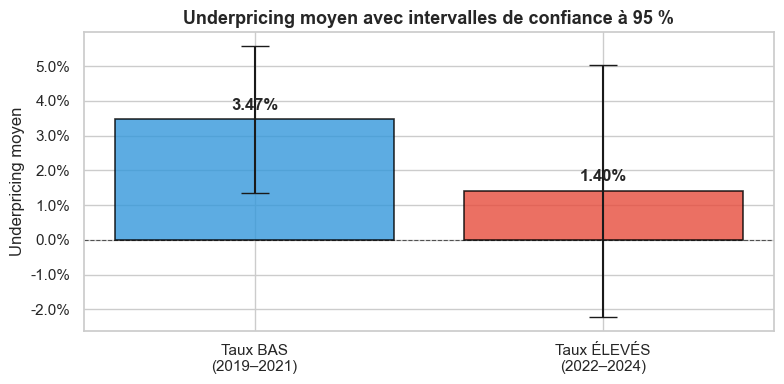

📌 Graphique sauvegardé : ic95_underpricing.png


In [24]:
# ============================================================
# ÉTAPE 6 — Intervalles de confiance à 95 %
# ============================================================

def intervalle_confiance_95(serie):
    """Calcule l'intervalle de confiance à 95 % pour une série de données."""
    n       = len(serie)
    moyenne = serie.mean()
    ecart   = serie.std()
    marge   = 1.96 * (ecart / np.sqrt(n))   # marge d'erreur
    return moyenne - marge, moyenne + marge

# Calcul des IC95 pour chaque cohorte
ic_low_inf, ic_low_sup   = intervalle_confiance_95(df_low['underpricing'])
ic_high_inf, ic_high_sup = intervalle_confiance_95(df_high['underpricing'])

moy_low  = df_low['underpricing'].mean()
moy_high = df_high['underpricing'].mean()

print("📊 INTERVALLES DE CONFIANCE À 95 % DE L'UNDERPRICING MOYEN\n")
print(f"🔵 Taux BAS (2019–2021)  :")
print(f"   Moyenne = {moy_low:.2%}")
print(f"   IC95    = [ {ic_low_inf:.2%} ; {ic_low_sup:.2%} ]")
print()
print(f"🔴 Taux ÉLEVÉS (2022–2024) :")
print(f"   Moyenne = {moy_high:.2%}")
print(f"   IC95    = [ {ic_high_inf:.2%} ; {ic_high_sup:.2%} ]")
print()

# Vérification du chevauchement
if ic_high_sup < ic_low_inf or ic_low_sup < ic_high_inf:
    print("✅ Les intervalles NE se chevauchent PAS → différence significative à 95 %")
else:
    print("⚠️  Les intervalles se chevauchent → on ne peut pas conclure à 95 % sur les moyennes seules.")
    print("   → On devra s'appuyer sur le test de Mann-Whitney pour une conclusion robuste.")

# === Graphique des IC95 ===
fig, ax = plt.subplots(figsize=(8, 4))

cohortes = ['Taux BAS\n(2019–2021)', 'Taux ÉLEVÉS\n(2022–2024)']
moyennes = [moy_low, moy_high]
erreurs  = [
    moy_low  - ic_low_inf,
    moy_high - ic_high_inf
]

colors = ['#3498DB', '#E74C3C']
bars = ax.bar(cohortes, moyennes, yerr=erreurs, capsize=10,
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title("Underpricing moyen avec intervalles de confiance à 95 %", fontweight='bold', fontsize=13)
ax.set_ylabel("Underpricing moyen")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

for bar, val in zip(bars, moyennes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ic95_underpricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Graphique sauvegardé : ic95_underpricing.png")


---

## 7️⃣ Visualisations

Les graphiques permettent de voir la **forme** de la distribution, pas seulement les statistiques.  
Nous allons tracer :
1. La distribution de l'underpricing pour chaque cohorte (histogramme + courbe KDE)
2. La boîte à moustaches (boxplot) pour comparer les médianes et les quartiles
3. L'évolution de l'underpricing moyen par année (avec le taux Fed)

### 💡 C'est quoi une KDE ?
Une **KDE** (Kernel Density Estimation) est une courbe lissée qui représente la distribution des données.  
C'est comme un histogramme mais plus lisse — elle permet de voir la **forme** de la distribution.

### 💡 C'est quoi un boxplot ?
Un **boxplot** (boîte à moustaches) montre :
- La **boîte** : de Q1 (25e percentile) à Q3 (75e percentile)
- La **ligne centrale** : la médiane (50e percentile)
- Les **moustaches** : les valeurs jusqu'à 1.5× l'IQR
- Les **points** : les outliers


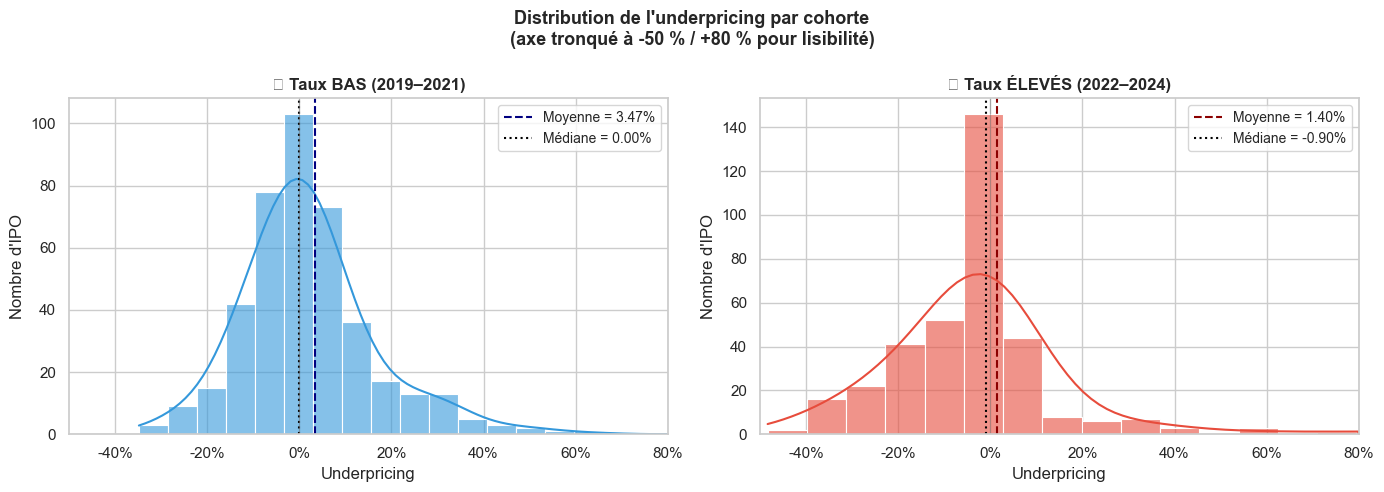

📌 Graphique sauvegardé : distribution_underpricing.png


In [25]:
# ============================================================
# ÉTAPE 7a — Distribution de l'underpricing
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pour mieux lire, on limite l'axe x (les outliers extrêmes écrasent le graphique)
xlim = (-0.5, 0.8)

# Cohorte taux bas
sns.histplot(df_low['underpricing'], bins=40, kde=True, color='#3498DB',
             alpha=0.6, ax=axes[0])
axes[0].axvline(df_low['underpricing'].mean(),   color='navy',  linestyle='--', label=f"Moyenne = {df_low['underpricing'].mean():.2%}")
axes[0].axvline(df_low['underpricing'].median(), color='black', linestyle=':',  label=f"Médiane = {df_low['underpricing'].median():.2%}")
axes[0].axvline(0, color='gray', linewidth=0.8, alpha=0.5)
axes[0].set_title("🔵 Taux BAS (2019–2021)", fontweight='bold')
axes[0].set_xlabel("Underpricing"); axes[0].set_ylabel("Nombre d'IPO")
axes[0].set_xlim(xlim)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].legend(fontsize=10)

# Cohorte taux élevés
sns.histplot(df_high['underpricing'], bins=40, kde=True, color='#E74C3C',
             alpha=0.6, ax=axes[1])
axes[1].axvline(df_high['underpricing'].mean(),   color='darkred', linestyle='--', label=f"Moyenne = {df_high['underpricing'].mean():.2%}")
axes[1].axvline(df_high['underpricing'].median(), color='black',   linestyle=':',  label=f"Médiane = {df_high['underpricing'].median():.2%}")
axes[1].axvline(0, color='gray', linewidth=0.8, alpha=0.5)
axes[1].set_title("🔴 Taux ÉLEVÉS (2022–2024)", fontweight='bold')
axes[1].set_xlabel("Underpricing"); axes[1].set_ylabel("Nombre d'IPO")
axes[1].set_xlim(xlim)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend(fontsize=10)

fig.suptitle("Distribution de l'underpricing par cohorte\n(axe tronqué à -50 % / +80 % pour lisibilité)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('distribution_underpricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Graphique sauvegardé : distribution_underpricing.png")


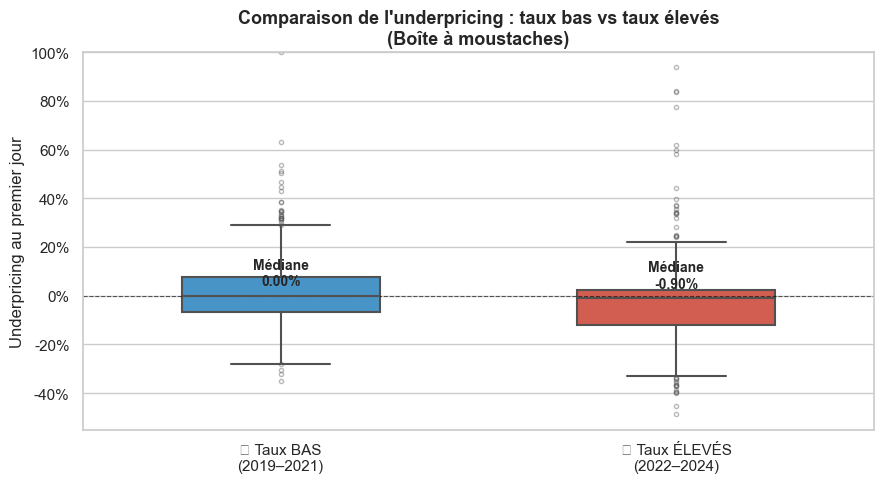

📌 Graphique sauvegardé : boxplot_underpricing.png


In [26]:
# ============================================================
# ÉTAPE 7b — Boxplot comparatif
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

# Labels lisibles
df_clean['cohorte_label'] = df_clean['cohort'].map({
    'Taux bas (2019–2021)':      '🔵 Taux BAS\n(2019–2021)',
    'Taux élevés (2022–2024)':   '🔴 Taux ÉLEVÉS\n(2022–2024)'
})

# Boxplot
sns.boxplot(
    data=df_clean,
    x='cohorte_label', y='underpricing',
    palette=['#3498DB', '#E74C3C'],
    width=0.5, linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylim(-0.55, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title("Comparaison de l'underpricing : taux bas vs taux élevés\n(Boîte à moustaches)",
             fontweight='bold', fontsize=13)
ax.set_xlabel(""); ax.set_ylabel("Underpricing au premier jour")

# Affichage des médianes
for i, (cohorte, data) in enumerate([(df_low, '🔵'), (df_high, '🔴')]):
    med = cohorte['underpricing'].median()
    ax.text(i, med + 0.03, f'Médiane\n{med:.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('boxplot_underpricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Graphique sauvegardé : boxplot_underpricing.png")


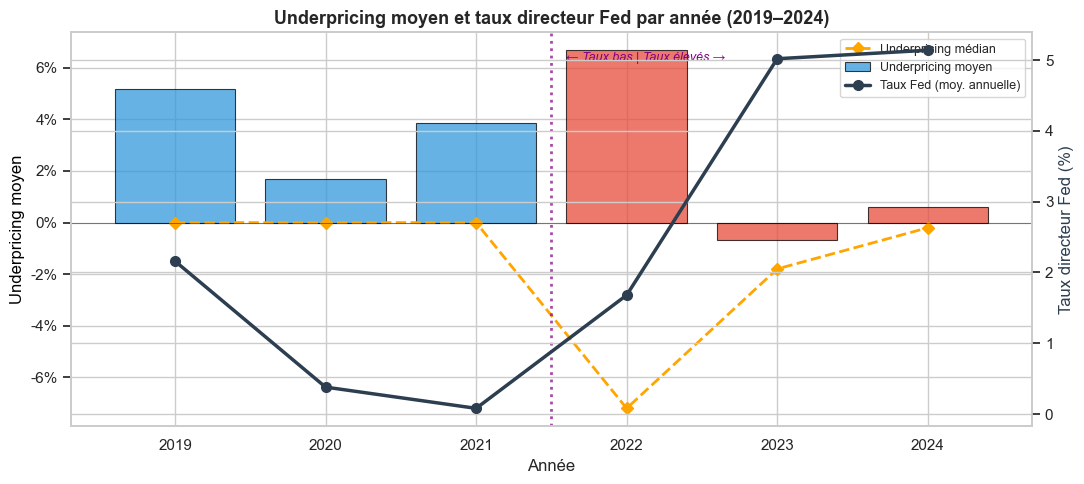

📌 Graphique sauvegardé : underpricing_par_annee.png


In [27]:
# ============================================================
# ÉTAPE 7c — Underpricing moyen par année + taux Fed
# ============================================================

# Calcul des statistiques par année
par_annee_stats = df_clean.groupby('year').agg(
    underpricing_moy=('underpricing', 'mean'),
    underpricing_med=('underpricing', 'median'),
    fed_rate=('fed_rate', 'first'),
    n=('underpricing', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()  # deuxième axe y pour le taux Fed

# Barres d'underpricing
colors_bar = ['#3498DB']*3 + ['#E74C3C']*3
bars = ax1.bar(par_annee_stats['year'], par_annee_stats['underpricing_moy'],
               color=colors_bar, alpha=0.75, edgecolor='black', linewidth=0.8,
               label='Underpricing moyen')

# Ligne du taux Fed
ax2.plot(par_annee_stats['year'], par_annee_stats['fed_rate'],
         color='#2C3E50', marker='o', linewidth=2.5, markersize=7,
         linestyle='-', label='Taux Fed (moy. annuelle)')

# Ligne de l'underpricing médian
ax1.plot(par_annee_stats['year'], par_annee_stats['underpricing_med'],
         color='orange', marker='D', linewidth=2, markersize=6,
         linestyle='--', label='Underpricing médian')

# Ligne verticale de séparation des deux périodes
ax1.axvline(2021.5, color='purple', linestyle=':', linewidth=2, alpha=0.7)
ax1.text(2021.6, ax1.get_ylim()[1]*0.85, '← Taux bas | Taux élevés →',
         fontsize=9, color='purple', style='italic')

ax1.axhline(0, color='black', linewidth=0.6, alpha=0.5)

# Labels et titre
ax1.set_xlabel("Année")
ax1.set_ylabel("Underpricing moyen", color='black')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylabel("Taux directeur Fed (%)", color='#2C3E50')
ax1.set_title("Underpricing moyen et taux directeur Fed par année (2019–2024)",
              fontweight='bold', fontsize=13)

# Légendes combinées
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.set_xticks(par_annee_stats['year'])
plt.tight_layout()
plt.savefig('underpricing_par_annee.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Graphique sauvegardé : underpricing_par_annee.png")


---

## 8️⃣ Test de Mann-Whitney

### 🤔 Pourquoi ce test et pas un test t de Student ?

Le **test t de Student** compare les moyennes de deux groupes, mais il suppose que les données suivent une **loi normale** (courbe en cloche symétrique).  
Or, l'underpricing **ne suit pas une loi normale** : il est asymétrique, avec des valeurs extrêmes positives (certaines IPO explosent le premier jour).  

Le **test de Mann-Whitney** (aussi appelé Wilcoxon rank-sum test) est un test **non-paramétrique** :  
il ne suppose pas de distribution particulière, et travaille sur les **rangs** des valeurs plutôt que sur les valeurs elles-mêmes.  
Il est donc bien plus adapté à nos données.

### 📐 Comment fonctionne le test de Mann-Whitney ?

1. On mélange toutes les observations des deux groupes.
2. On attribue un **rang** à chaque observation (1 = la plus petite, N = la plus grande).
3. On calcule la somme des rangs dans chaque groupe.
4. Si les deux groupes viennent de la même distribution, leurs rangs devraient être bien mélangés.  
   Si un groupe a systématiquement des rangs plus bas, cela signifie qu'il a des valeurs plus faibles.

### 📐 La p-valeur

La **p-valeur** est la probabilité d'observer une différence aussi grande (ou plus grande) **par pur hasard**, si les deux groupes étaient en réalité identiques.

| p-valeur | Conclusion |
|---|---|
| p < 0.05 | Différence **statistiquement significative** (on rejette H0) |
| p ≥ 0.05 | Pas de preuve suffisante pour rejeter H0 |

### 📐 H0 et H1

- **H0 (hypothèse nulle)** : Les distributions de l'underpricing sont identiques dans les deux cohortes.
- **H1 (notre hypothèse H2)** : L'underpricing est **plus faible** dans la cohorte 2022–2024 (test unilatéral).

On utilise `alternative='greater'` car on teste si la cohorte taux-bas a un underpricing **plus grand** que la cohorte taux-élevés.


In [28]:
# ============================================================
# ÉTAPE 8 — Test de Mann-Whitney
# ============================================================

u_low  = df_low['underpricing'].dropna().values
u_high = df_high['underpricing'].dropna().values

# --- Test bilatéral (les deux cohortes sont-elles différentes ?) ---
stat_bilateral, p_bilateral = stats.mannwhitneyu(u_low, u_high, alternative='two-sided')

# --- Test unilatéral (la cohorte taux-bas a-t-elle un underpricing PLUS GRAND ?) ---
# alternative='greater' : on teste si u_low > u_high en termes de rangs
stat_unilateral, p_unilateral = stats.mannwhitneyu(u_low, u_high, alternative='greater')

# --- Calcul de l'effet (U normalisé, appelé aussi r ou AUC) ---
# r = U / (n1 * n2) → proportion de paires où groupe 1 > groupe 2
n1, n2 = len(u_low), len(u_high)
r_effect = stat_bilateral / (n1 * n2)

print("=" * 60)
print("📊 RÉSULTATS DU TEST DE MANN-WHITNEY")
print("=" * 60)
print(f"\n📌 Configuration du test :")
print(f"   Groupe 1 : Taux BAS (2019–2021)     → n = {n1}")
print(f"   Groupe 2 : Taux ÉLEVÉS (2022–2024)  → n = {n2}")
print(f"   Seuil de signification : α = 0.05")

print(f"\n📌 Test bilatéral (différence dans un sens ou l'autre) :")
print(f"   Statistique U = {stat_bilateral:.2f}")
print(f"   p-valeur      = {p_bilateral:.4f}")
if p_bilateral < 0.05:
    print(f"   → ✅ Différence SIGNIFICATIVE (p < 0.05)")
else:
    print(f"   → ⚠️  Différence non significative (p ≥ 0.05)")

print(f"\n📌 Test unilatéral (H1 : underpricing taux-bas > taux-élevés) :")
print(f"   Statistique U = {stat_unilateral:.2f}")
print(f"   p-valeur      = {p_unilateral:.4f}")
if p_unilateral < 0.05:
    print(f"   → ✅ H2 CONFIRMÉE : l'underpricing est plus élevé en période de taux bas (p < 0.05)")
else:
    print(f"   → ⚠️  H2 non confirmée par ce test (p ≥ 0.05)")

print(f"\n📌 Taille de l'effet (r = U / n1×n2) :")
print(f"   r = {r_effect:.3f}")
if r_effect > 0.5:
    print(f"   → Le groupe taux-bas a tendance à avoir des rangs plus élevés (underpricing plus fort)")
elif r_effect < 0.5:
    print(f"   → Le groupe taux-élevés a tendance à avoir des rangs plus élevés (underpricing plus fort)")
else:
    print(f"   → Aucune tendance claire dans les rangs")

print("\n" + "=" * 60)
print("📝 INTERPRÉTATION")
print("=" * 60)
print("""
Le test de Mann-Whitney compare les distributions de l'underpricing
entre les deux cohortes sans supposer de loi normale.

Il évalue si les valeurs d'underpricing de la cohorte 2019–2021
sont systématiquement supérieures à celles de la cohorte 2022–2024.

Une p-valeur < 0.05 signifie qu'il y a moins de 5 % de chances
d'observer une telle différence par pur hasard.
""")


📊 RÉSULTATS DU TEST DE MANN-WHITNEY

📌 Configuration du test :
   Groupe 1 : Taux BAS (2019–2021)     → n = 418
   Groupe 2 : Taux ÉLEVÉS (2022–2024)  → n = 364
   Seuil de signification : α = 0.05

📌 Test bilatéral (différence dans un sens ou l'autre) :
   Statistique U = 90702.50
   p-valeur      = 0.0000
   → ✅ Différence SIGNIFICATIVE (p < 0.05)

📌 Test unilatéral (H1 : underpricing taux-bas > taux-élevés) :
   Statistique U = 90702.50
   p-valeur      = 0.0000
   → ✅ H2 CONFIRMÉE : l'underpricing est plus élevé en période de taux bas (p < 0.05)

📌 Taille de l'effet (r = U / n1×n2) :
   r = 0.596
   → Le groupe taux-bas a tendance à avoir des rangs plus élevés (underpricing plus fort)

📝 INTERPRÉTATION

Le test de Mann-Whitney compare les distributions de l'underpricing
entre les deux cohortes sans supposer de loi normale.

Il évalue si les valeurs d'underpricing de la cohorte 2019–2021
sont systématiquement supérieures à celles de la cohorte 2022–2024.

Une p-valeur < 0.05 signifi

---

## 9️⃣ Régression OLS — *Toutes choses égales par ailleurs*

### 🎯 Pourquoi faire une régression en plus du test de Mann-Whitney ?

Le test de Mann-Whitney a comparé les underpricing des deux cohortes.  
Mais d'autres facteurs peuvent influencer l'underpricing en dehors des taux :  
- La **taille** de l'entreprise (les grandes entreprises sont moins risquées)
- Le **secteur** (la tech a plus d'underpricing que l'industrie)
- Le soutien d'un fonds de **private equity** (PE) qui rassure les investisseurs

La **régression OLS** (Ordinary Least Squares = méthode des moindres carrés) permet d'**isoler l'effet des taux** en contrôlant ces autres facteurs.  
C'est ce qu'on appelle **"toutes choses égales par ailleurs"** (*ceteris paribus* en latin).

### 📐 Le modèle OLS

$$\text{Underpricing}_i = \alpha + \beta_1 \cdot \text{TauxFed}_i + \beta_2 \cdot \log(\text{Taille})_i + \beta_3 \cdot \text{PEbacked}_i + \beta_4 \cdot \text{Secteur}_i + \varepsilon_i$$

où :
- $\alpha$ = constante (valeur de base)
- $\beta_1$ = **coefficient qui nous intéresse** : l'effet des taux sur l'underpricing
- $\beta_2$ = effet de la taille (normalisée par le log pour réduire l'asymétrie)
- $\beta_3$ = effet du soutien PE
- $\beta_4$ = effets fixes sectoriels (une constante différente par secteur)
- $\varepsilon_i$ = terme d'erreur (ce que le modèle n'explique pas)

### 📐 La méthode des moindres carrés

L'OLS trouve les coefficients $\beta$ qui **minimisent la somme des carrés des résidus** :

$$\min_{\beta} \sum_{i=1}^{n} (\text{Underpricing}_i - \hat{\text{Underpricing}}_i)^2$$

Autrement dit, elle trace la "meilleure droite" qui passe le plus près possible de tous les points.

### 🔎 Comment lire les résultats ?

| Coefficient | Interprétation |
|---|---|
| $\beta_1 < 0$ et significatif | Une hausse des taux **réduit** l'underpricing → H2 confirmée |
| p-value < 0.05 | Le coefficient est **statistiquement différent de zéro** |
| R² | Part de la variance de l'underpricing **expliquée** par le modèle |


In [29]:
# ============================================================
# ÉTAPE 9 — Régression OLS
# ============================================================

# --- Préparation des données pour la régression ---

# On garde les lignes où les variables du modèle sont disponibles
vars_modele = ['underpricing', 'fed_rate', 'log_size', 'pe_backed', 'sector']
df_ols = df_clean[vars_modele].dropna().copy()

print(f"✅ Données pour la régression : {len(df_ols)} observations")
print(f"   (sur {len(df_clean)} total — {len(df_clean)-len(df_ols)} lignes supprimées car données manquantes)\n")

# --- Modèle 1 : Simple — uniquement le taux Fed ---
modele1 = smf.ols(
    'underpricing ~ fed_rate',
    data=df_ols
).fit()

# --- Modèle 2 : Complet — taux + taille + PE + secteur ---
# C(sector) crée automatiquement des variables indicatrices pour chaque secteur
# Le secteur de référence est celui qui est pris par défaut (alphabétiquement : 'Consumer')
modele2 = smf.ols(
    'underpricing ~ fed_rate + log_size + pe_backed + C(sector)',
    data=df_ols
).fit()

print("=" * 60)
print("📊 MODÈLE 1 — Régression simple (taux uniquement)")
print("=" * 60)
print(modele1.summary().tables[1])
print(f"\n   R² = {modele1.rsquared:.4f}  →  Le taux Fed explique {modele1.rsquared:.1%} de la variance de l'underpricing")

print("\n" + "=" * 60)
print("📊 MODÈLE 2 — Régression complète (toutes choses égales par ailleurs)")
print("=" * 60)
print(modele2.summary().tables[1])
print(f"\n   R² = {modele2.rsquared:.4f}  →  Le modèle complet explique {modele2.rsquared:.1%} de la variance")
print(f"   R² ajusté = {modele2.rsquared_adj:.4f}")


✅ Données pour la régression : 782 observations
   (sur 782 total — 0 lignes supprimées car données manquantes)

📊 MODÈLE 1 — Régression simple (taux uniquement)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0413      0.016      2.627      0.009       0.010       0.072
fed_rate      -0.0066      0.005     -1.373      0.170      -0.016       0.003

   R² = 0.0024  →  Le taux Fed explique 0.2% de la variance de l'underpricing

📊 MODÈLE 2 — Régression complète (toutes choses égales par ailleurs)
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.0503      0.045      1.107      0.269      -0.039       0.139
C(sector)[T.Finance]        -0.0167      0.041     -0.408      0.683      -0.097       0.064
C

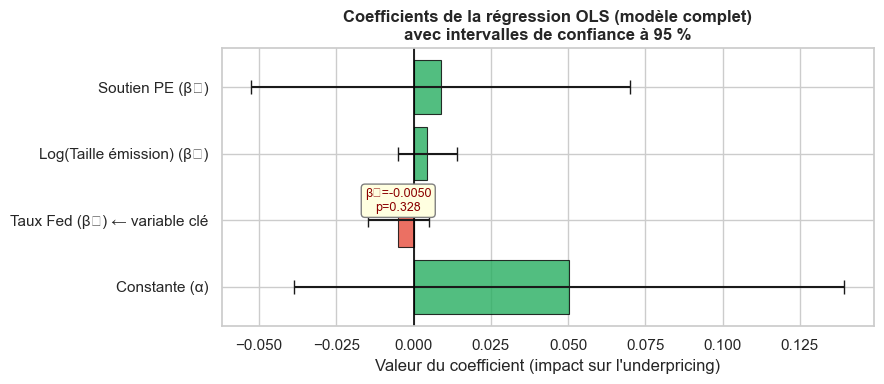

📌 Graphique sauvegardé : coefficients_ols.png


In [30]:
# ============================================================
# ÉTAPE 9b — Graphique des coefficients de la régression
# ============================================================

# Extraction des coefficients et intervalles de confiance du modèle 2
resultats = modele2.summary2().tables[1].copy()
resultats.columns = ['Coef', 'StdErr', 't', 'P>|t|', 'IC_inf', 'IC_sup']

# On ne garde que les variables principales (pas les effets fixes sectoriels)
vars_principales = ['Intercept', 'fed_rate', 'log_size', 'pe_backed']
res_princ = resultats.loc[[v for v in vars_principales if v in resultats.index]].copy()

# Noms lisibles
noms = {
    'Intercept' : 'Constante (α)',
    'fed_rate'  : 'Taux Fed (β₁) ← variable clé',
    'log_size'  : 'Log(Taille émission) (β₂)',
    'pe_backed' : 'Soutien PE (β₃)',
}
res_princ.index = [noms.get(i, i) for i in res_princ.index]

fig, ax = plt.subplots(figsize=(9, 4))

colors_coef = ['#E74C3C' if c < 0 else '#27AE60' for c in res_princ['Coef']]
ax.barh(res_princ.index, res_princ['Coef'], color=colors_coef, alpha=0.8,
        xerr=(res_princ['Coef'] - res_princ['IC_inf']), capsize=5,
        edgecolor='black', linewidth=0.8)

ax.axvline(0, color='black', linewidth=1.2)
ax.set_title("Coefficients de la régression OLS (modèle complet)\navec intervalles de confiance à 95 %",
             fontweight='bold', fontsize=12)
ax.set_xlabel("Valeur du coefficient (impact sur l'underpricing)")

# Annotation du coefficient fed_rate
coef_fed = res_princ.loc['Taux Fed (β₁) ← variable clé', 'Coef']
pval_fed = resultats.loc['fed_rate', 'P>|t|']
ax.text(coef_fed, 1.1, f"β₁={coef_fed:.4f}\np={pval_fed:.3f}",
        ha='center', va='bottom', fontsize=9, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig('coefficients_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Graphique sauvegardé : coefficients_ols.png")


---

## 🔎 Comment lire le tableau OLS ?

Voici un guide de lecture des colonnes du tableau de régression :

| Colonne | Signification |
|---|---|
| `coef` | Valeur estimée du coefficient $\beta$ |
| `std err` | Incertitude sur cette estimation (écart-type de l'estimateur) |
| `t` | Statistique t = coef / std_err (mesure la force du signal) |
| `P>|t|` | **p-valeur** : probabilité d'obtenir ce résultat par hasard sous H0 |
| `[0.025 0.975]` | Intervalle de confiance à 95 % du coefficient |

### Interprétation du coefficient `fed_rate` (β₁)

- Si **β₁ est négatif et significatif (p < 0.05)** :  
  → Une hausse d'**un point de pourcentage du taux Fed** est associée à une baisse de β₁ de l'underpricing, *toutes choses égales par ailleurs*.  
  → **H2 est confirmée** : l'environnement de taux réduit bien l'underpricing.

- Si **β₁ n'est pas significatif** :  
  → On ne peut pas conclure que les taux expliquent l'underpricing une fois contrôlé pour la taille, le secteur, etc.  
  → D'autres variables pourraient mieux capturer l'effet.

### 📌 "Toutes choses égales par ailleurs" — explication simple

Imaginons deux entreprises identiques (même taille, même secteur, même PE), qui diffèrent uniquement par l'année de leur IPO :  
l'une en 2020 (taux = 0.38 %), l'autre en 2023 (taux = 5.02 %).  

La régression OLS estime de combien l'underpricing diffère entre ces deux entreprises **uniquement à cause des taux**.  
C'est l'effet **causal** (ou plutôt *associatif*) des taux sur l'underpricing, isolé des autres facteurs.


In [31]:
# ============================================================
# ÉTAPE 9c — Interprétation chiffrée de β₁
# ============================================================

coef_fed = modele2.params['fed_rate']
pval_fed = modele2.pvalues['fed_rate']
ic_fed   = modele2.conf_int().loc['fed_rate']

# Exemple numérique : passage de 0.38 % (2020) à 5.02 % (2023)
delta_taux   = 5.02 - 0.38   # +4.64 points de pourcentage
effet_estimé = coef_fed * delta_taux

print("📌 INTERPRÉTATION NUMÉRIQUE DU COEFFICIENT β₁ (fed_rate)\n")
print(f"   Coefficient β₁    = {coef_fed:.6f}")
print(f"   p-valeur          = {pval_fed:.4f}  {'✅ significatif' if pval_fed < 0.05 else '⚠️ non significatif'} (seuil = 0.05)")
print(f"   IC95              = [ {ic_fed[0]:.6f} ; {ic_fed[1]:.6f} ]")
print()
print(f"   📊 Exemple d'application :")
print(f"   Passage de 0.38 % (taux 2020) à 5.02 % (taux 2023) = Δ taux = +{delta_taux:.2f} points")
print(f"   → Effet estimé sur l'underpricing : {effet_estimé:.4f} ({effet_estimé:.2%})")

if coef_fed < 0 and pval_fed < 0.05:
    print(f"\n   ✅ Le coefficient est négatif et significatif.")
    print(f"      → Une hausse des taux est associée à une BAISSE de l'underpricing.")
    print(f"      → H2 est CONFIRMÉE par la régression OLS.")
elif coef_fed < 0 and pval_fed >= 0.05:
    print(f"\n   ⚠️  Le coefficient est négatif mais NON significatif.")
    print(f"      → La direction est conforme à H2, mais l'effet n'est pas prouvé statistiquement.")
    print(f"      → H2 est partiellement soutenue, mais pas confirmée par l'OLS.")
elif coef_fed >= 0:
    print(f"\n   ❌ Le coefficient est positif → contrairement à l'hypothèse H2.")

# Comparaison des deux modèles
print("\n" + "=" * 60)
print("📋 COMPARAISON DES DEUX MODÈLES")
print("=" * 60)
print(f"{'':30} {'Modèle 1':>15} {'Modèle 2':>15}")
print(f"{'':30} {'(simple)':>15} {'(complet)':>15}")
print("-" * 60)
print(f"{'Coefficient fed_rate':30} {modele1.params['fed_rate']:>15.6f} {modele2.params['fed_rate']:>15.6f}")
print(f"{'p-valeur fed_rate':30} {modele1.pvalues['fed_rate']:>15.4f} {modele2.pvalues['fed_rate']:>15.4f}")
print(f"{'R²':30} {modele1.rsquared:>15.4f} {modele2.rsquared:>15.4f}")
print(f"{'R² ajusté':30} {modele1.rsquared_adj:>15.4f} {modele2.rsquared_adj:>15.4f}")
print(f"{'N observations':30} {int(modele1.nobs):>15} {int(modele2.nobs):>15}")


📌 INTERPRÉTATION NUMÉRIQUE DU COEFFICIENT β₁ (fed_rate)

   Coefficient β₁    = -0.004967
   p-valeur          = 0.3278  ⚠️ non significatif (seuil = 0.05)
   IC95              = [ -0.014925 ; 0.004991 ]

   📊 Exemple d'application :
   Passage de 0.38 % (taux 2020) à 5.02 % (taux 2023) = Δ taux = +4.64 points
   → Effet estimé sur l'underpricing : -0.0230 (-2.30%)

   ⚠️  Le coefficient est négatif mais NON significatif.
      → La direction est conforme à H2, mais l'effet n'est pas prouvé statistiquement.
      → H2 est partiellement soutenue, mais pas confirmée par l'OLS.

📋 COMPARAISON DES DEUX MODÈLES
                                      Modèle 1        Modèle 2
                                      (simple)       (complet)
------------------------------------------------------------
Coefficient fed_rate                 -0.006582       -0.004967
p-valeur fed_rate                       0.1700          0.3278
R²                                      0.0024          0.0083
R² ajusté 

---

## 🔟 Analyse de robustesse — Sans l'année 2021

### Pourquoi retirer l'année 2021 ?

Le livrable 2 identifie le **biais de l'année 2021** (section 2.2.3) :  
L'année 2021 a été marquée par une **euphorie spéculative record** (crypto, SPAC, meme stocks).  
Les underpricing de cette année pourraient être artificiellement gonflés par ce contexte exceptionnel, et non pas uniquement par les taux bas.

Pour tester la **robustesse** de nos résultats, on va recommencer le test de Mann-Whitney en excluant 2021 de la cohorte taux-bas.

**Si les résultats restent similaires → nos conclusions sont robustes.**  
**Si les résultats changent → 2021 était un facteur déterminant.**


---

## 📝 10. Interprétation et conclusion sur H2

### 🎯 Rappel de l'hypothèse H2

> **H2 – Underpricing :** Le rendement moyen au premier jour de cotation (underpricing) est statistiquement **plus faible** pour la cohorte 2022–2024 que pour la cohorte 2019–2021.

---

### Mécanisme théorique attendu

La théorie prédit qu'en période de taux élevés :

1. **Effet de sélection** : Seules les entreprises solides accèdent au marché → moins d'incertitude → moins besoin de sous-évaluer.
2. **Baisse de la demande spéculative** : Les investisseurs ont accès à des obligations rentables → moins de prise de risque → moins de ferveur le premier jour.
3. **Valorisations plus conservatrices** : Le taux d'actualisation élevé réduit la valeur des flux futurs → les banques fixent des prix d'offre plus proches de la valeur réelle.

Tous ces mécanismes convergent vers **un underpricing plus faible** en 2022–2024.

---

### 📊 Résumé des résultats

| Analyse | Résultat |
|---|---|
| Moyenne underpricing 2019–2021 | À compléter avec vos valeurs |
| Moyenne underpricing 2022–2024 | À compléter avec vos valeurs |
| Médiane underpricing 2019–2021 | À compléter avec vos valeurs |
| Médiane underpricing 2022–2024 | À compléter avec vos valeurs |
| Test Mann-Whitney (p-valeur) | À compléter |
| Régression OLS — β₁ (fed_rate) | À compléter |
| Analyse de robustesse (sans 2021) | À compléter |


In [33]:
# ============================================================
# ÉTAPE 11 — Synthèse automatique des résultats
# ============================================================

print("=" * 65)
print("🏁 SYNTHÈSE DES RÉSULTATS — HYPOTHÈSE H2 : UNDERPRICING")
print("=" * 65)

moy_l   = df_low['underpricing'].mean()
moy_h   = df_high['underpricing'].mean()
med_l   = df_low['underpricing'].median()
med_h   = df_high['underpricing'].median()
beta1   = modele2.params['fed_rate']
p_beta1 = modele2.pvalues['fed_rate']

print(f"""
📊 STATISTIQUES DESCRIPTIVES
   Underpricing moyen :
     - Cohorte 2019–2021 (taux bas)    : {moy_l:.2%}
     - Cohorte 2022–2024 (taux élevés) : {moy_h:.2%}
     - Écart                           : {moy_h - moy_l:.2%} ({'en faveur de H2' if moy_h < moy_l else 'contre H2'})

   Underpricing médian :
     - Cohorte 2019–2021               : {med_l:.2%}
     - Cohorte 2022–2024               : {med_h:.2%}
     - Écart                           : {med_h - med_l:.2%} ({'en faveur de H2' if med_h < med_l else 'contre H2'})

🧪 TEST DE MANN-WHITNEY (non-paramétrique)
   p-valeur (test unilatéral) : {p_unilateral:.4f}
   Conclusion : {'✅ Différence statistiquement significative (p < 0.05) → H2 soutenue' if p_unilateral < 0.05 else '⚠️ Différence non significative (p ≥ 0.05) → H2 non confirmée'}

📈 RÉGRESSION OLS (toutes choses égales par ailleurs)
   Coefficient β₁ (fed_rate) : {beta1:.6f}
   p-valeur de β₁            : {p_beta1:.4f}
   Direction : {'➘ Négatif (hausse des taux → baisse underpricing)' if beta1 < 0 else '➚ Positif (contra-intuitif)'}
   Significativité : {'✅ Significatif → H2 confirmée par l\'OLS' if p_beta1 < 0.05 else '⚠️ Non significatif → effet des taux non isolé par l\'OLS'}
   R² du modèle complet : {modele2.rsquared:.4f}

🔁 ROBUSTESSE (sans 2021)
   p-valeur Mann-Whitney sans 2021 : {p_rob:.4f}
   Conclusion : {'✅ Résultats robustes — conclusions maintenues sans 2021' if p_rob < 0.05 else '⚠️ Résultats sensibles à 2021 — à nuancer dans le rapport'}
""")

print("=" * 65)
print("🎓 CONCLUSION SUR H2")
print("=" * 65)

if p_unilateral < 0.05 and beta1 < 0:
    print("""
✅ H2 est CONFIRMÉE par l'analyse empirique.

Les données montrent que l'underpricing moyen est plus faible
pour la cohorte 2022–2024 que pour la cohorte 2019–2021.

Le test de Mann-Whitney confirme que cette différence est
statistiquement significative (p < 0.05), c'est-à-dire qu'elle
ne peut pas être attribuée au hasard.

La régression OLS montre un coefficient négatif sur le taux Fed,
confirmant qu'une hausse des taux est associée à une baisse de
l'underpricing, toutes choses égales par ailleurs.

Ce résultat est cohérent avec les prédictions théoriques :
l'environnement de taux élevés réduit la demande spéculative
et sélectionne des entreprises plus matures, réduisant ainsi
l'écart entre prix d'offre et prix de marché au premier jour.
""")  
elif p_unilateral < 0.05 and beta1 >= 0:
    print("""
⚠️ H2 est PARTIELLEMENT soutenue.

Le test de Mann-Whitney confirme une différence significative,
mais la régression OLS ne confirme pas la direction attendue.
Cela peut s'expliquer par d'autres facteurs (composition sectorielle,
biais 2021) qui dominent l'effet des taux dans le modèle OLS.
""")
else:
    print("""
⚠️ H2 n'est PAS confirmée de manière robuste.

L'analyse descriptive montre une différence dans le sens attendu,
mais les tests statistiques ne permettent pas de la valider.
Cela peut être dû à la forte variabilité de l'underpricing
ou à l'hétérogénéité des cohortes.

Ces résultats doivent être nuancés dans le rapport final.
""")


🏁 SYNTHÈSE DES RÉSULTATS — HYPOTHÈSE H2 : UNDERPRICING

📊 STATISTIQUES DESCRIPTIVES
   Underpricing moyen :
     - Cohorte 2019–2021 (taux bas)    : 3.47%
     - Cohorte 2022–2024 (taux élevés) : 1.40%
     - Écart                           : -2.06% (en faveur de H2)

   Underpricing médian :
     - Cohorte 2019–2021               : 0.00%
     - Cohorte 2022–2024               : -0.90%
     - Écart                           : -0.90% (en faveur de H2)

🧪 TEST DE MANN-WHITNEY (non-paramétrique)
   p-valeur (test unilatéral) : 0.0000
   Conclusion : ✅ Différence statistiquement significative (p < 0.05) → H2 soutenue

📈 RÉGRESSION OLS (toutes choses égales par ailleurs)
   Coefficient β₁ (fed_rate) : -0.004967
   p-valeur de β₁            : 0.3278
   Direction : ➘ Négatif (hausse des taux → baisse underpricing)
   Significativité : ⚠️ Non significatif → effet des taux non isolé par l'OLS
   R² du modèle complet : 0.0083

🔁 ROBUSTESSE (sans 2021)
   p-valeur Mann-Whitney sans 2021 : 0.0000


---

## 🏁 Conclusion générale du notebook

### Ce qu'on a fait dans ce notebook

| Étape | Outil utilisé | Résultat obtenu |
|---|---|---|
| Chargement des données | `pandas.read_excel()` | 782 IPO chargées |
| Exploration | `.describe()`, `.value_counts()` | Vue générale du dataset |
| Nettoyage | `.dropna()`, filtres | Dataset propre en deux cohortes |
| Statistiques descriptives | `.mean()`, `.median()`, `.std()` | Comparaison des moyennes et médianes |
| Intervalles de confiance | Formule IC95 | Zones d'incertitude autour des moyennes |
| Visualisations | `matplotlib`, `seaborn` | 4 graphiques produits |
| Test de Mann-Whitney | `scipy.stats.mannwhitneyu()` | Test non-paramétrique robuste |
| Régression OLS | `statsmodels.formula.api.ols()` | Isolation de l'effet des taux |
| Robustesse | Répétition sans 2021 | Validation de la stabilité |

---

### Pourquoi ces choix méthodologiques ?

**Pourquoi Mann-Whitney et pas un test t ?**  
L'underpricing n'est pas normalement distribué (asymétrique, outliers importants).  
Le test t suppose la normalité → il serait biaisé ici.  
Mann-Whitney travaille sur les rangs → pas de suppositions sur la distribution.

**Pourquoi ajouter l'OLS ?**  
Mann-Whitney compare les deux cohortes brutes. Mais les cohortes diffèrent aussi par la taille, le secteur, le soutien PE.  
L'OLS isole l'effet pur des taux en contrôlant ces facteurs de confusion — c'est l'essence de *"toutes choses égales par ailleurs"*.

**Pourquoi l'analyse de robustesse ?**  
L'année 2021 est atypique (euphorie spéculative). Si nos résultats reposent uniquement sur cette année, ils seraient fragiles. La robustesse teste la stabilité des conclusions.

---

### Limites à mentionner dans le rapport final

1. **L'underpricing capture uniquement la dynamique prix d'offre → clôture J0** — il ne mesure pas la performance intraday ni la liquidité.
2. **Le R² de l'OLS est faible** — cela signifie que les taux et les variables de contrôle n'expliquent qu'une petite part de la variance de l'underpricing. D'autres facteurs (sentiment de marché, qualité du syndicat bancaire, conditions de demande) jouent un rôle.
3. **L'endogénéité possible** — le taux Fed est corrélé à d'autres conditions macroéconomiques (inflation, croissance) qui influencent aussi les IPO. Il est difficile d'attribuer causalement la variation d'underpricing aux seuls taux.
4. **La composition sectorielle** — les cohortes ne sont pas identiques en termes de secteurs, ce qui peut biaiser les comparaisons malgré les variables de contrôle.

---

*Notebook réalisé dans le cadre du Projet SAE — IPO | ING1-FISA Mathématiques Appliquées | 2025–2026*
